In [20]:
"""
Created on: 18-08-2026

@author B.A. Sturre

PyTorch tutorial 
https://www.youtube.com/watch?v=c36lUUr864M 
"""

import matplotlib.pyplot as plt 
import numpy as np 
import torch
import torch.nn as nn
import torch.nn.functional as F 
import torchvision
import torchvision.transforms as transforms

## Convolutional Neural Networks

We will use the CIFAR-10 dataset of 60000 32x32 colour images in 10 classes, with 6000 images per class. 

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_epochs = 20
batch_size = 20
learning_rate = 0.001

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

# CIFAR10: 60000 32x32 color images in 10 classes, with 6000 images per class
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


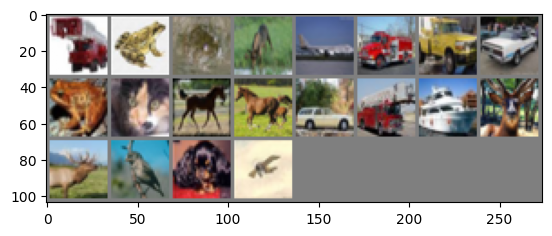

torch.Size([20, 3, 32, 32])
torch.Size([20, 6, 28, 28])
torch.Size([20, 6, 14, 14])
torch.Size([20, 16, 10, 10])
torch.Size([20, 16, 5, 5])


In [22]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

conv1 = nn.Conv2d(3, 6, 5)
pool = nn.MaxPool2d(2, 2)
conv2 = nn.Conv2d(6, 16, 5)
print(images.shape)
x = conv1(images)
print(x.shape)
x = pool(x)
print(x.shape)
x = conv2(x)
print(x.shape)
x = pool(x)
print(x.shape)

In [23]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)  # input channel size = 3 (3 colour channel), output channel size = 6, kernel size = 5
        self.pool = nn.MaxPool2d(2, 2)  # pooling size 2x2
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 120) # 16*5*5: we want to flatten it into the first linear layer
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10) # 10 different classes

    def forward(self, x):
        # -> n, 3, 32, 32
        x = self.pool(F.relu(self.conv1(x)))  # -> n, 6, 14, 14
        x = self.pool(F.relu(self.conv2(x)))  # -> n, 16, 5, 5
        x = x.view(-1, 16 * 5 * 5)            # -> n, 400
        x = F.relu(self.fc1(x))               # -> n, 120
        x = F.relu(self.fc2(x))               # -> n, 84
        x = self.fc3(x)                       # -> n, 10
        return x

model = ConvNet().to(device)

# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# training loop 
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader): 
        # origin shape: [4, 3, 32, 32] = 4, 3, 1024
        # input_layer: 3 input channels, 6 output channels, 5 kernel size
        images = images.to(device)
        labels = labels.to(device)

        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 2500 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')
print('Finished Training')

PATH = './cnn.pth'
torch.save(model.state_dict(), PATH)

Epoch [1/20], Step [2500/2500], Loss: 2.2916
Epoch [2/20], Step [2500/2500], Loss: 2.2953
Epoch [3/20], Step [2500/2500], Loss: 2.2523
Epoch [4/20], Step [2500/2500], Loss: 2.1905
Epoch [5/20], Step [2500/2500], Loss: 2.2664
Epoch [6/20], Step [2500/2500], Loss: 2.1090
Epoch [7/20], Step [2500/2500], Loss: 1.7765
Epoch [8/20], Step [2500/2500], Loss: 2.0197
Epoch [9/20], Step [2500/2500], Loss: 1.6163
Epoch [10/20], Step [2500/2500], Loss: 1.6255
Epoch [11/20], Step [2500/2500], Loss: 1.5731
Epoch [12/20], Step [2500/2500], Loss: 1.3594
Epoch [13/20], Step [2500/2500], Loss: 1.3901
Epoch [14/20], Step [2500/2500], Loss: 1.4911
Epoch [15/20], Step [2500/2500], Loss: 1.4686
Epoch [16/20], Step [2500/2500], Loss: 1.3673
Epoch [17/20], Step [2500/2500], Loss: 1.2957
Epoch [18/20], Step [2500/2500], Loss: 1.4211
Epoch [19/20], Step [2500/2500], Loss: 1.6766
Epoch [20/20], Step [2500/2500], Loss: 1.4213
Finished Training


In [24]:
# evaluation 
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(10)]
    n_class_samples = [0 for i in range(10)]
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()
        
        for i in range(batch_size):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    for i in range(10):
        acc = 100.0 * n_class_correct[i] / n_class_samples[i]
        print(f'Accuracy of {classes[i]}: {acc} %')


Accuracy of the network: 49.08 %
Accuracy of plane: 50.6 %
Accuracy of car: 67.9 %
Accuracy of bird: 28.0 %
Accuracy of cat: 16.2 %
Accuracy of deer: 27.6 %
Accuracy of dog: 55.3 %
Accuracy of frog: 75.5 %
Accuracy of horse: 56.2 %
Accuracy of ship: 56.0 %
Accuracy of truck: 57.5 %
